## Problem Definition

This dataset contains information about houses and their characteristics such as area, number of bedrooms, bathrooms, and price. The goal of this dataset is to analyze the relationship between these features and house prices.

The main questions explored in this project include:
- How does the area of a house affect its price?
- Do houses with more bedrooms or bathrooms have higher prices?
- What features have the strongest relationship with house prices?

Through this analysis, we expect to uncover patterns and relationships between house features and price. These insights can help understand which factors influence house prices the most and identify any unusual patterns or outliers in the data.



## Dataset Overview

Dataset Title:
Saudi Arabia Real Estate (AQAR)

Source:
https://www.kaggle.com/datasets/lama122/saudi-arabia-real-estate-aqar/data

Description:
This dataset contains information about real estate properties in Saudi Arabia collected from the Aqar platform. It includes housing data from major cities such as Riyadh, Jeddah, Dammam, and Al-Khobar. The dataset includes features like property size, number of bedrooms, bathrooms, and price, which allows us to analyze patterns in the real estate market.

Why I Selected This Dataset:
I selected this dataset because real estate analysis is an important real-world problem. The dataset allows exploration of how different property features affect housing prices and helps identify patterns in the Saudi real estate market.

In [1]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Load the dataset using pandas
df = pd.read_csv("SA_Aqar.csv")

In [7]:
# Display the first five rows of the dataset
# This helps us understand the structure of the data

df.head()

,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,...,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price,details
0,الرياض,حي العارض,شمال,250,0,5,5,1,1,1,...,0,0,1,0,1,1,0,0,80000,للايجار فيلا دبلكس في موقع ممتاز جدا بالقرب من...
1,الرياض,حي القادسية,جنوب,370,0,4,5,2,1,1,...,0,0,1,0,0,1,0,0,60000,*** فيلا درج مع الصالة جديدة ***\n\nعبارة عن م...
2,الرياض,حي القادسية,جنوب,380,0,4,5,1,1,1,...,1,0,1,0,0,1,0,0,60000,فيلا للايجار درج داخلي مشب خارجي مجلس مقلط وصا...
3,الرياض,حي المعيزلة,غرب,250,0,5,5,3,0,1,...,0,0,1,0,0,0,0,0,55000,فيلا للايجار جديده لن تستخدم ش...
4,الرياض,حي العليا,غرب,400,11,7,5,2,1,1,...,1,0,1,0,1,1,0,0,70000,فيلا للايجار حي العليا \n\nالارضي مجالس وغرفتي...


In [8]:
# Check the shape of the dataset
# This shows the number of rows and columns

df.shape

(3718, 24)

###The dataset contains 3718 property listings and 24 features describing different aspects of the properties.

In [9]:
# Display information about the dataset
# Shows column names, data types, and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3718 entries, 0 to 3717
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   city          3718 non-null   object
 1   district      3718 non-null   object
 2   front         3718 non-null   object
 3   size          3718 non-null   int64 
 4   property_age  3718 non-null   int64 
 5   bedrooms      3718 non-null   int64 
 6   bathrooms     3718 non-null   int64 
 7   livingrooms   3718 non-null   int64 
 8   kitchen       3718 non-null   int64 
 9   garage        3718 non-null   int64 
 10  driver_room   3718 non-null   int64 
 11  maid_room     3718 non-null   int64 
 12  furnished     3718 non-null   int64 
 13  ac            3718 non-null   int64 
 14  roof          3718 non-null   int64 
 15  pool          3718 non-null   int64 
 16  frontyard     3718 non-null   int64 
 17  basement      3718 non-null   int64 
 18  duplex        3718 non-null   int64 
 19  stairs

### Data Structure Observations

The dataset contains **3718 rows** and **24 columns** representing different characteristics of real estate properties in Saudi Arabia.

Most of the columns are numerical features (`int64`) such as size, number of bedrooms, bathrooms, and price. These variables describe the physical characteristics of the properties.

There are also some categorical columns (`object`) such as city, district, front, and details which represent location and descriptive information.

The column **details** contains **missing values** (3638 non-null out of 3718), while the rest of the dataset appears to have complete data.


In [10]:
# Generate statistical summary of numerical columns

df.describe()

,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,driver_room,maid_room,furnished,ac,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price
count,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3.718000e+03
mean,390.968531,5.064820,5.083916,4.606509,2.243948,0.909360,0.802044,0.495697,0.795320,0.123453,0.560785,0.521517,0.162453,0.802582,0.034158,0.499462,0.814416,0.080958,0.181280,8.738797e+04
std,1565.056135,7.590427,1.230040,0.703449,0.916436,0.287135,0.398512,0.500049,0.403522,0.329001,0.496358,0.499604,0.368915,0.398104,0.181660,0.500067,0.388823,0.272807,0.385302,7.063470e+04
min,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+03
25%,280.000000,0.000000,4.000000,4.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,5.500000e+04
50%,330.000000,2.000000,5.000000,5.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,7.000000e+04
75%,400.000000,7.000000,6.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000e+05
max,95000.000000,36.000000,7.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.700000e+06


### Statistical Summary Observations

The statistical summary shows key information about the numerical features in the dataset.

The average property size is approximately **391 square meters**, although the maximum size reaches **95,000**, which suggests the presence of potential outliers.

On average, houses contain about **5 bedrooms** and **4 to 5 bathrooms**, indicating that most properties in the dataset are relatively large family houses.

The average house price is around **87,388**, while the maximum price reaches **1,700,000**, showing a wide variation in property prices across the dataset.

These statistics provide an initial understanding of the distribution of property features and prices before performing deeper exploratory data analysis.


In [11]:
df.duplicated().sum()

np.int64(2197)

### Duplicate Records

The dataset contains **2197 duplicated rows**, which indicates that a significant portion of the data is repeated. Duplicate records can negatively affect data analysis and lead to misleading insights.

To ensure data quality and improve the accuracy of the analysis, duplicate rows will be removed during the data cleaning step.


In [12]:
# Remove duplicate rows

df = df.drop_duplicates()

df.shape

(1521, 24)

After removing duplicate records, the dataset now contains fewer rows and more reliable data for analysis.


In [14]:
# Check missing values again

df.isnull().sum()

,0
city,0
district,0
front,0
size,0
property_age,0
bedrooms,0
bathrooms,0
livingrooms,0
kitchen,0
garage,0


In [15]:
# Drop the column with missing values

df = df.drop("details", axis=1)

### Handling Missing Values

The column **details** contains missing values. Since this column is not essential for the analysis and mainly contains textual information, it was removed from the dataset to simplify the analysis process.


In [16]:
df.columns

Index(['city', 'district', 'front', 'size', 'property_age', 'bedrooms',
       'bathrooms', 'livingrooms', 'kitchen', 'garage', 'driver_room',
       'maid_room', 'furnished', 'ac', 'roof', 'pool', 'frontyard', 'basement',
       'duplex', 'stairs', 'elevator', 'fireplace', 'price'],
      dtype='object')

In [17]:
df.nunique()

,0
city,4
district,174
front,10
size,199
property_age,36
bedrooms,7
bathrooms,5
livingrooms,5
kitchen,2
garage,2


### Unique Values Analysis

The dataset contains several categorical and numerical features. The **city** column has **4 unique values**, indicating that the dataset includes properties from four different cities. The **district** column has **174 unique values**, which shows a wide geographic distribution of properties.

Several features such as **garage, furnished, ac, pool, and basement** contain only **two unique values (0 and 1)**, indicating that these variables represent binary features (presence or absence of a feature).

The **price** column has **113 unique values**, suggesting that property prices vary across the dataset but still fall within a limited number of price levels.


In [33]:
# Save cleaned dataset

df.to_csv("clean_real_estate_data.csv", index=False)

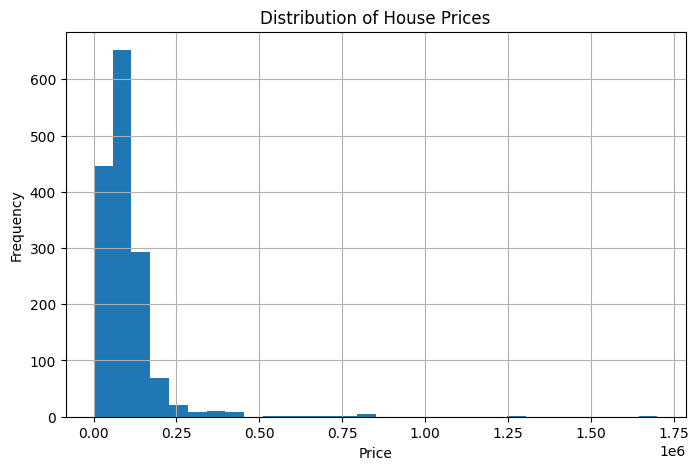

In [18]:
# Histogram for house prices

plt.figure(figsize=(8,5))

df["price"].hist(bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Price Distribution

The histogram shows the distribution of property prices in the dataset. Most properties fall within the lower and middle price ranges. The distribution is right-skewed, meaning that a small number of properties have significantly higher prices compared to the majority of listings.


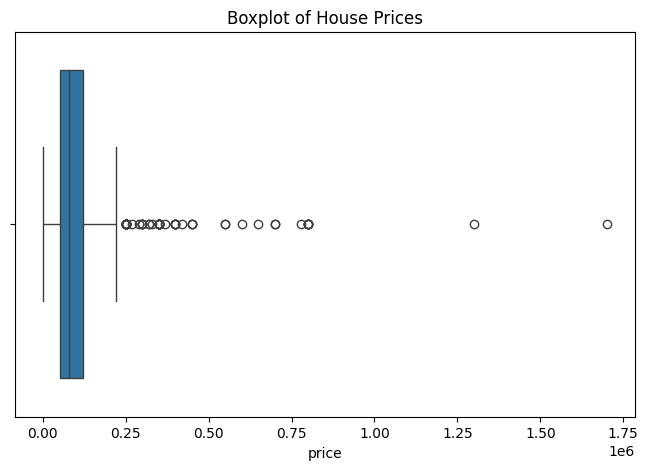

In [19]:
# Boxplot for house prices to detect outliers

plt.figure(figsize=(8,5))

sns.boxplot(x=df["price"])

plt.title("Boxplot of House Prices")

plt.show()

### Price Outliers

The boxplot shows several outliers in the price distribution. These outliers represent properties with significantly higher prices compared to most listings. In real estate datasets, such extreme values may represent luxury or premium properties rather than data errors, so they are kept in the dataset for further analysis.


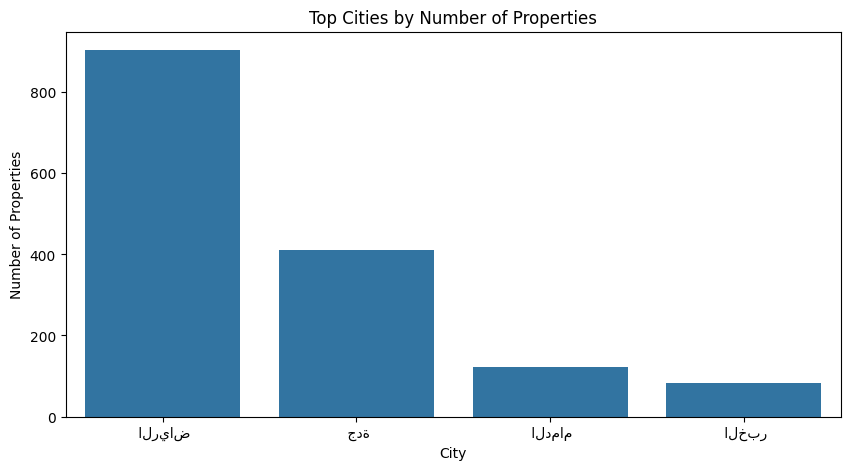

In [22]:
# Top cities by number of properties

plt.figure(figsize=(10,5))

top_cities = df["city"].value_counts().head(10)

sns.barplot(x=top_cities.index, y=top_cities.values)

plt.title("Top Cities by Number of Properties")
plt.xlabel("City")
plt.ylabel("Number of Properties")

plt.xticks(rotation=0)

plt.show()

### City Distribution

The bar chart shows the distribution of properties across different cities. One city clearly has the highest number of property listings compared to the others, indicating a higher concentration of real estate activity in that location.


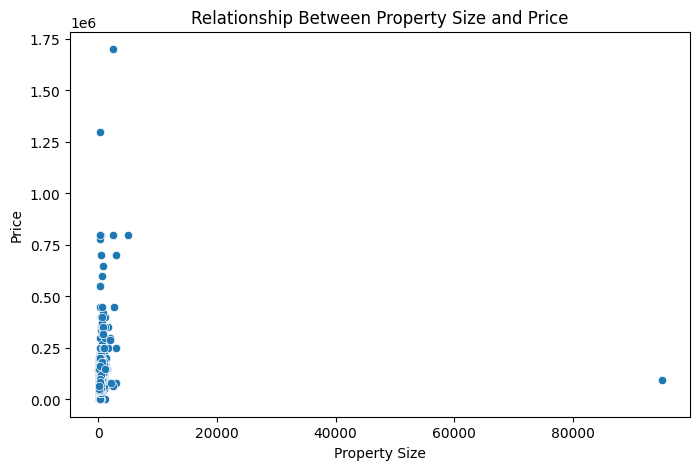

In [23]:
# Scatter plot between property size and price

plt.figure(figsize=(8,5))

sns.scatterplot(x="size", y="price", data=df)

plt.title("Relationship Between Property Size and Price")
plt.xlabel("Property Size")
plt.ylabel("Price")

plt.show()

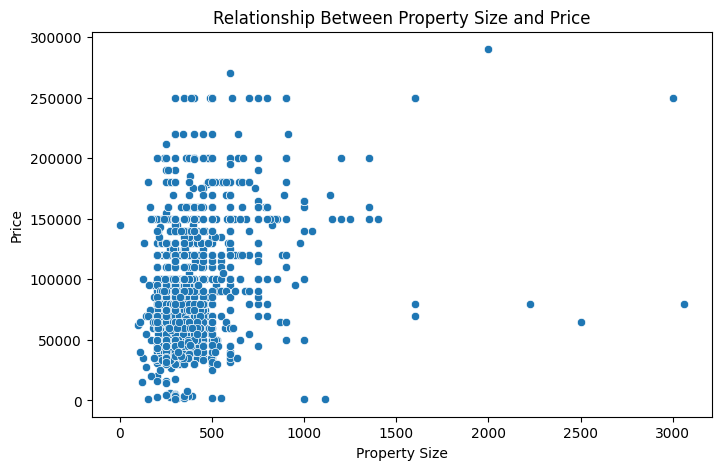

In [24]:
filtered_df = df[(df["size"] < 10000) & (df["price"] < 300000)]

plt.figure(figsize=(8,5))

sns.scatterplot(x="size", y="price", data=filtered_df)

plt.title("Relationship Between Property Size and Price")
plt.xlabel("Property Size")
plt.ylabel("Price")

plt.show()

### Size vs Price Relationship

The scatter plot shows the relationship between property size and price. In general, larger properties tend to have higher prices. However, the relationship is not perfectly linear, as other factors such as location, property features, and age may also influence property prices.


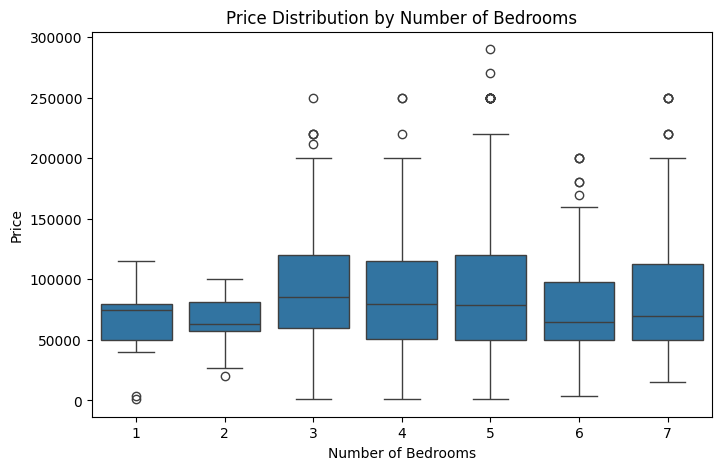

In [27]:
# Filter extreme price outliers for visualization

filtered_df = df[df["price"] < 300000]

plt.figure(figsize=(8,5))

sns.boxplot(x="bedrooms", y="price", data=filtered_df)

plt.title("Price Distribution by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")

plt.show()

### Bedrooms vs Price

The boxplot illustrates how property prices vary depending on the number of bedrooms. Generally, properties with more bedrooms tend to have higher prices. However, there is considerable overlap in price ranges between different bedroom categories, suggesting that other factors such as property size, location, and amenities also influence the final property price.


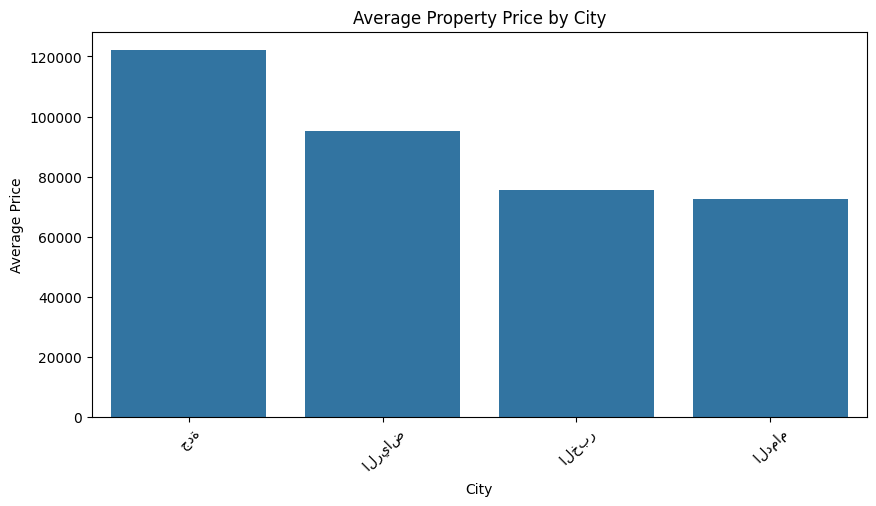

In [28]:
# Average price by city

avg_price_city = df.groupby("city")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=avg_price_city.index, y=avg_price_city.values)

plt.title("Average Property Price by City")
plt.xlabel("City")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

### Average Price by City

The bar chart shows the average property price across different cities. Jeddah has the highest average property price, followed by Riyadh, while Khobar and Dammam have relatively lower average prices. This indicates that location plays an important role in determining property values in the real estate market.


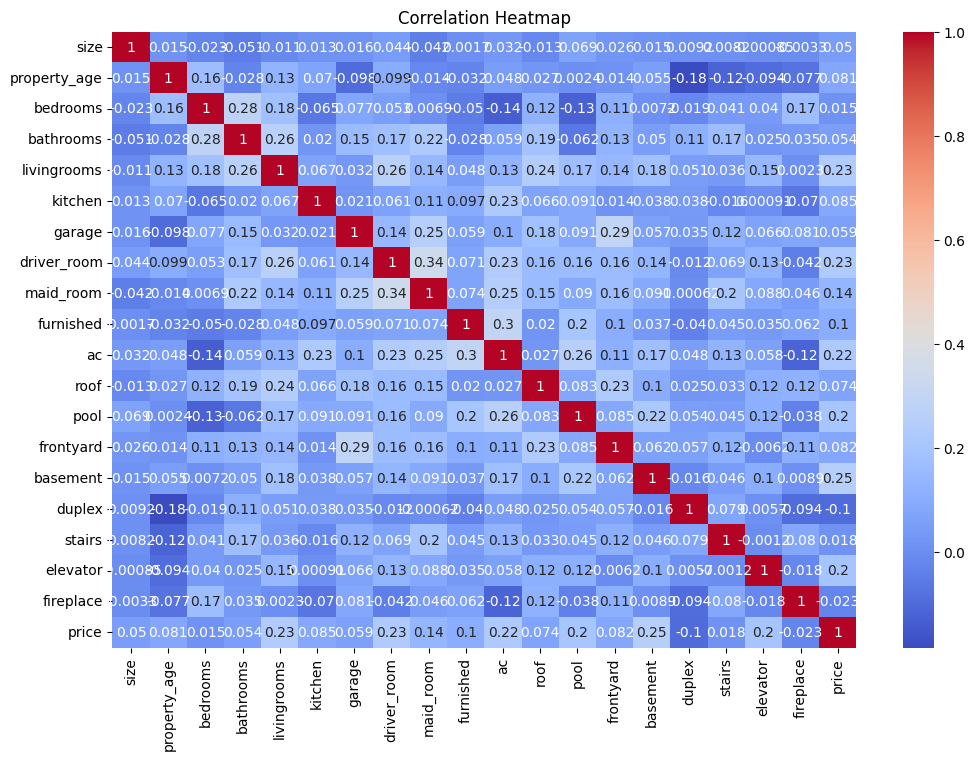

In [30]:
# Select only numeric columns

numeric_df = df.select_dtypes(include=["int64","float64"])

# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Correlation Analysis

The correlation heatmap shows the relationships between numerical variables in the dataset. Several features such as living rooms, driver rooms, pools, and basements show moderate positive correlations with property price. This suggests that properties with additional amenities and larger living spaces tend to have higher prices. However, no single variable shows a very strong correlation with price, indicating that property prices are influenced by multiple factors.


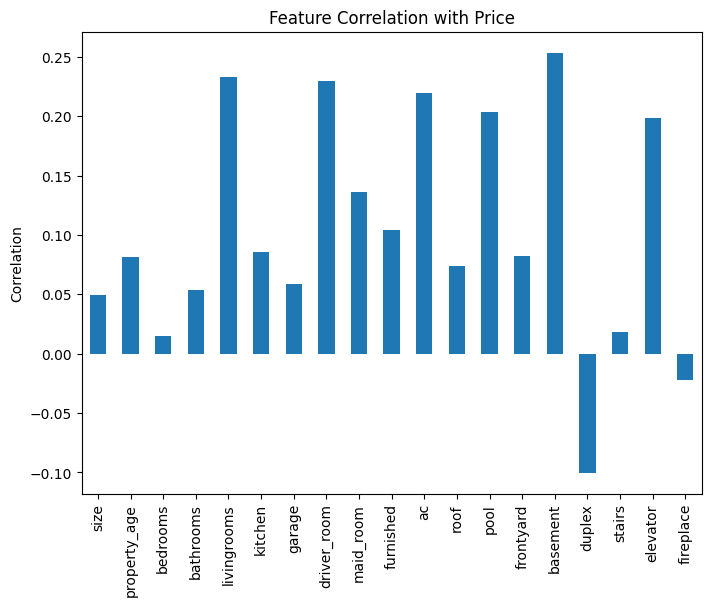

In [32]:
corr_price = numeric_df.corr()["price"]

plt.figure(figsize=(8,6))

corr_price.drop("price").plot(kind="bar")

plt.title("Feature Correlation with Price")
plt.ylabel("Correlation")

plt.show()

### Feature Correlation with Price

The bar chart illustrates the correlation between different property features and price. Features such as basement, living rooms, driver rooms, and air conditioning show the highest positive correlations with property price. This suggests that properties with more amenities and additional living space tend to have higher prices. However, most correlations are moderate, indicating that property price is influenced by multiple factors rather than a single dominant variable.


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [ ]:
df.columns

Index(['size', 'property_age', 'bedrooms', 'bathrooms', 'livingrooms',
       'kitchen', 'garage', 'driver_room', 'maid_room', 'furnished',
       ...
       'district_   حي منفوحة الجديدة ', 'front_4 شوارع', 'front_جنوب',
       'front_جنوب شرقي', 'front_جنوب غربي', 'front_شرق', 'front_شمال',
       'front_شمال شرقي', 'front_شمال غربي', 'front_غرب'],
      dtype='object', length=205)

In [ ]:
df = df.drop(columns=df.filter(like="district_").columns)

In [ ]:
df.columns

Index(['size', 'property_age', 'bedrooms', 'bathrooms', 'livingrooms',
       'kitchen', 'garage', 'driver_room', 'maid_room', 'furnished', 'ac',
       'roof', 'pool', 'frontyard', 'basement', 'duplex', 'stairs', 'elevator',
       'fireplace', 'price', 'city_ الدمام', 'city_ الرياض', 'city_ جدة',
       'front_4 شوارع', 'front_جنوب', 'front_جنوب شرقي', 'front_جنوب غربي',
       'front_شرق', 'front_شمال', 'front_شمال شرقي', 'front_شمال غربي',
       'front_غرب'],
      dtype='object')

In [ ]:
df.shape

(1479, 32)

###PART 2 ML


In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape, X_test.shape

((1183, 31), (296, 31))

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1517253012.1510897
R2 Score: 0.34993845970688753


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 1462088661.438033
Random Forest R2: 0.37357342533661997


###The analysis showed that property size, driver room availability, air conditioning, and property age have the strongest influence on house prices.
Among the tested models, Random Forest slightly outperformed Linear Regression with an R² score of about 0.37, indicating a moderate ability to capture price patterns in the dataset.

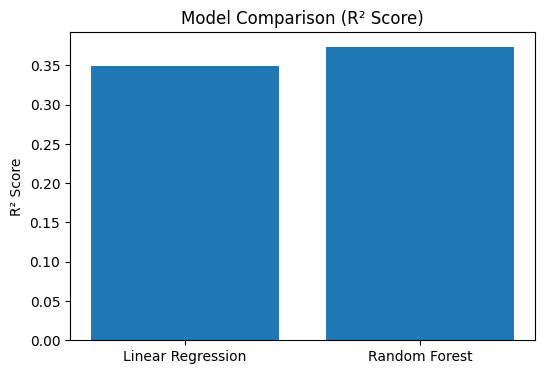

In [ ]:
models = ["Linear Regression", "Random Forest"]
scores = [r2, r2_rf]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()

###Random Forest performed slightly better than Linear Regression, achieving a higher R² score and showing a better ability to model the relationship between property features and price.

In [ ]:
df.to_csv("cleaned_house_data.csv", index=False)

In [ ]:
import joblib
joblib.dump(rf, "house_model.pkl")

['house_model.pkl']

In [ ]:
from google.colab import files
files.download("house_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>